# 02 · Training Runs and Results

The training itself runs via `train_arch.py` (hours per model); this notebook is the record.
It reproduces the full logs, the results tables of Section 5, and Figures 6, 7 and 9.

In [1]:
import sys, os, re
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../paper'))
%matplotlib inline
from pathlib import Path
import pandas as pd
LOGS = Path('../logs')
print('logs found:', sorted(p.name for p in LOGS.glob('*.log')))

logs found: ['cnn.log', 'cnn_full.log', 'cross.log', 'cross_extended_vit_ekush_to_ras.log', 'cross_extended_vit_matrivasha_to_ras.log', 'cross_extended_vit_ras_to_ekush.log', 'cross_extended_vit_ras_to_matrivasha.log', 'cross_resnet18_ekush_to_ras.log', 'cross_resnet18_matrivasha_to_ras.log', 'cross_resnet18_ras_to_ekush.log', 'cross_resnet18_ras_to_matrivasha.log', 'dashboard.log', 'extended_vit.log', 'extended_vit_imagenet.log', 'finalize.log', 'resnet18.log', 'run_all.log', 'run_cnn_full.log', 'seeds.log', 'sweep.log', 'sweep_extended_vit_100.log', 'sweep_extended_vit_1000.log', 'sweep_extended_vit_100_seed1.log', 'sweep_extended_vit_100_seed2.log', 'sweep_extended_vit_300.log', 'sweep_extended_vit_50.log', 'sweep_extended_vit_50_seed1.log', 'sweep_extended_vit_50_seed2.log', 'sweep_resnet18_100.log', 'sweep_resnet18_1000.log', 'sweep_resnet18_100_seed1.log', 'sweep_resnet18_100_seed2.log', 'sweep_resnet18_300.log', 'sweep_resnet18_50.log', 'sweep_resnet18_50_seed1.log', 'sweep_resn

## Training configuration

Every architecture shares `train_merged.py`'s manifest, transforms and seed-42 split, so all
runs see byte-identical data. Only the model varies.

In [2]:
from train_arch import ARCHS
for name, spec in ARCHS.items():
    print(f'{name:14s} default lr {spec["lr"]}')
print('''
Shared: AdamW (wd 1e-4), cross-entropy w/ label smoothing 0.1,
cosine anneal to 1e-6 over 8 epochs, batch 32, grad-clip 1.0,
backbone lr = 0.1 x base for pretrained models.''')

cnn            default lr 0.001
resnet18       default lr 0.0003
vit            default lr 0.0001
extended_vit   default lr 0.0003

Shared: AdamW (wd 1e-4), cross-entropy w/ label smoothing 0.1,
cosine anneal to 1e-6 over 8 epochs, batch 32, grad-clip 1.0,
backbone lr = 0.1 x base for pretrained models.


## Complete training logs

In [3]:
RUNS = [('cnn', '300/class'), ('resnet18', '300/class'), ('extended_vit', '300/class'),
        ('vit', '300/class'), ('extended_vit_imagenet', '300/class, ImageNet init'),
        ('cnn_full', 'full corpus')]
for stem, cond in RUNS:
    p = LOGS / f'{stem}.log'
    print('=' * 78)
    print(f'{stem}  ({cond})')
    print('=' * 78)
    if not p.exists():
        print('(not run)\n'); continue
    for line in p.read_text(errors='replace').splitlines():
        if any(k in line for k in ('Epoch [', 'Best Val', 'Test Acc', 'Total params',
                                   'Warm-started', 'Device', 'Train ', 'images,')):
            print(line)
    print()

cnn  (300/class)
Arch: cnn | Device: mps | LR: 0.001
681309 images, 256 classes, scanned in 2.1s
Train 56414 | Val 7035 | Test 7035
Total params: 62,208
Epoch [01/8] Train Loss: 4.9021 Acc: 0.0261 | Val Loss: 4.5406 Acc: 0.0583 | Time: 112.9s | Best Val: 0.0583
Epoch [02/8] Train Loss: 4.5128 Acc: 0.0621 | Val Loss: 4.2734 Acc: 0.0937 | Time: 100.5s | Best Val: 0.0937
Epoch [03/8] Train Loss: 4.3472 Acc: 0.0865 | Val Loss: 4.1396 Acc: 0.1171 | Time: 101.0s | Best Val: 0.1171
Epoch [04/8] Train Loss: 4.2366 Acc: 0.1055 | Val Loss: 4.0881 Acc: 0.1195 | Time: 101.6s | Best Val: 0.1195
Epoch [05/8] Train Loss: 4.1454 Acc: 0.1242 | Val Loss: 3.9950 Acc: 0.1468 | Time: 101.7s | Best Val: 0.1468
Epoch [06/8] Train Loss: 4.0824 Acc: 0.1372 | Val Loss: 3.8850 Acc: 0.1827 | Time: 101.6s | Best Val: 0.1827
Epoch [07/8] Train Loss: 4.0387 Acc: 0.1474 | Val Loss: 3.7918 Acc: 0.2151 | Time: 101.8s | Best Val: 0.2151
Epoch [08/8] Train Loss: 4.0145 Acc: 0.1538 | Val Loss: 3.7842 Acc: 0.2146 | Time: 1

## Results tables

In [4]:
for csv, title in [('../results_lpc300.csv', 'Equal budget (300 per class)'),
                   ('../results_lpc300_imagenet.csv', 'Equal budget, ImageNet-init ablation'),
                   ('../results_full.csv', 'Full corpus')]:
    print(f'\n### {title}')
    try:
        print(pd.read_csv(csv).to_string(index=False))
    except FileNotFoundError:
        print('(evaluate.py has not produced this yet)')


### Equal budget (300 per class)
      method  test_acc    CER  macro_f1  params_M  ckpt_MB  cpu_ms_per_img  eval_s  acc_Ekush  acc_MatriVasha  acc_RAS
extended_vit    0.9719 0.0281    0.9739     23.94     95.9             9.3    52.5     0.9672          0.9753   0.9953
         vit    0.9662 0.0338    0.9689     86.33    345.4            38.2   134.6     0.9624          0.9683   0.9953
    resnet18    0.9544 0.0456    0.9577     11.31     45.3             6.7    48.0     0.9507          0.9566   0.9812
         cnn    0.2115 0.7885    0.1934      0.06      0.3             1.4    39.2     0.2472          0.1593   0.4366

### Equal budget, ImageNet-init ablation
      method  test_acc    CER  macro_f1  params_M  ckpt_MB  cpu_ms_per_img  eval_s  acc_Ekush  acc_MatriVasha  acc_RAS
extended_vit    0.9576 0.0424    0.9609     23.94     95.9             9.3    52.0     0.9541          0.9593   0.9906

### Full corpus
      method  test_acc    CER  macro_f1    NLL    ECE  mean_conf  params_M

## Figures 6, 7 and 9

In [5]:
from figures import fig6_training_curves, fig7_results, fig9_efficiency
for fn in (fig6_training_curves, fig7_results, fig9_efficiency):
    fn(); print(fn.__name__, 'written')

fig6_training_curves written


fig7_results written


/Users/uthsob/reasearch/bornomal-pm/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


fig9_efficiency written


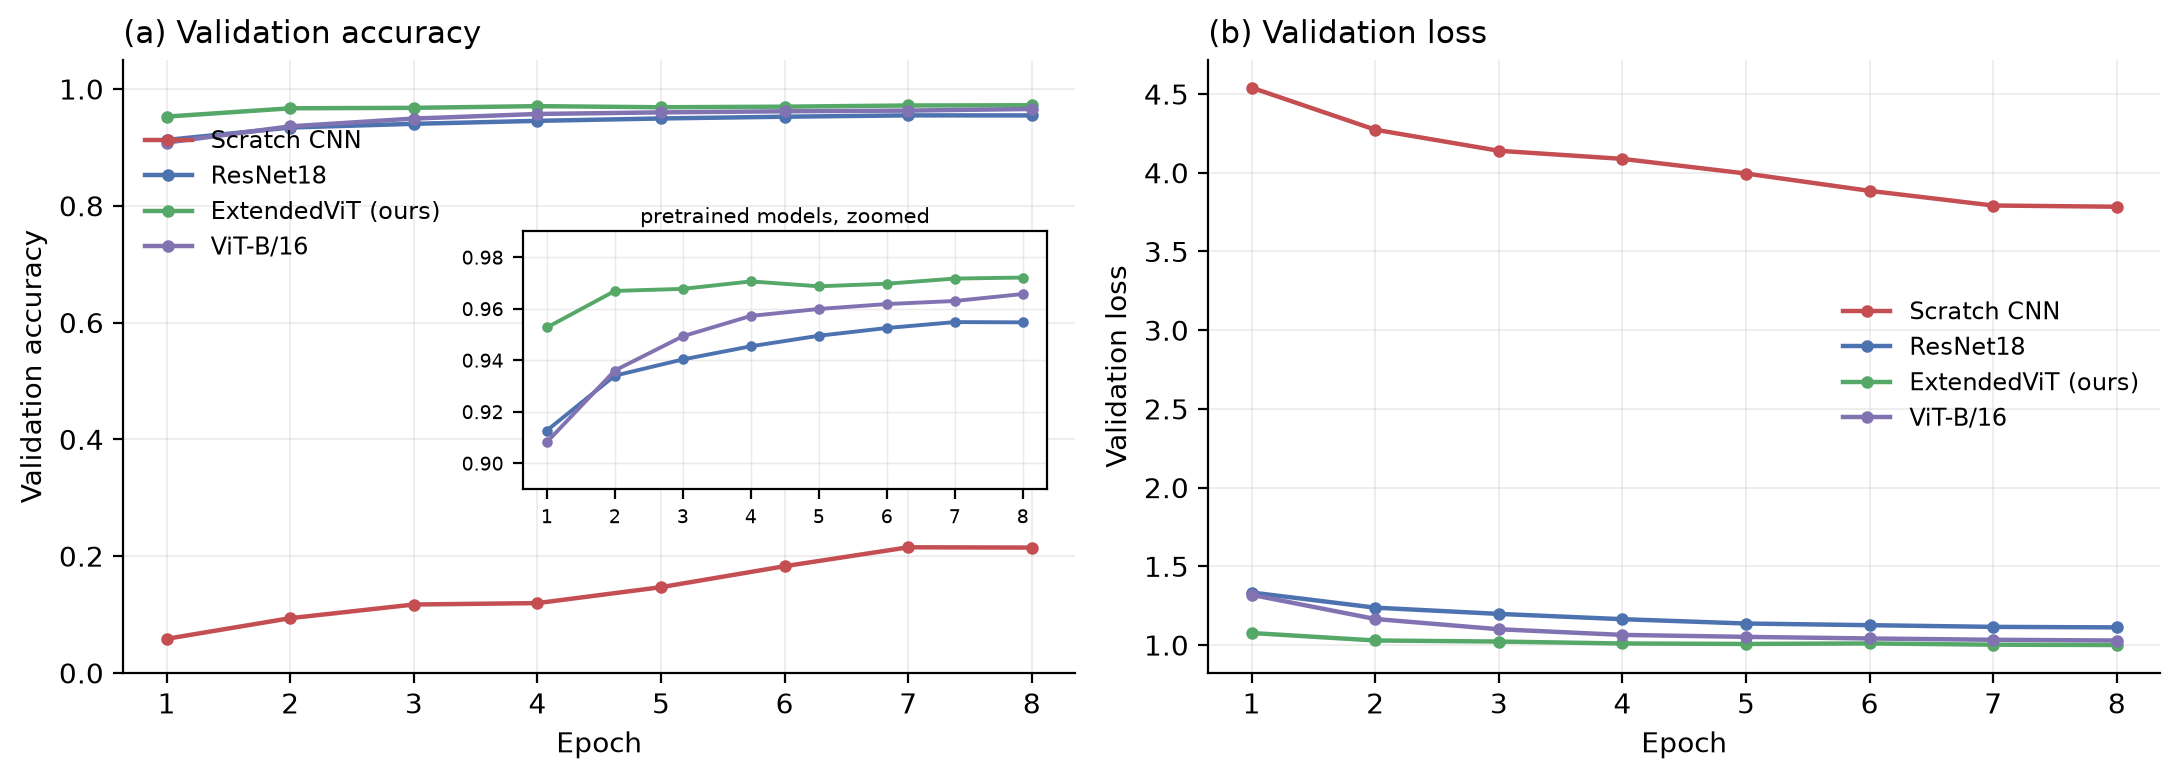

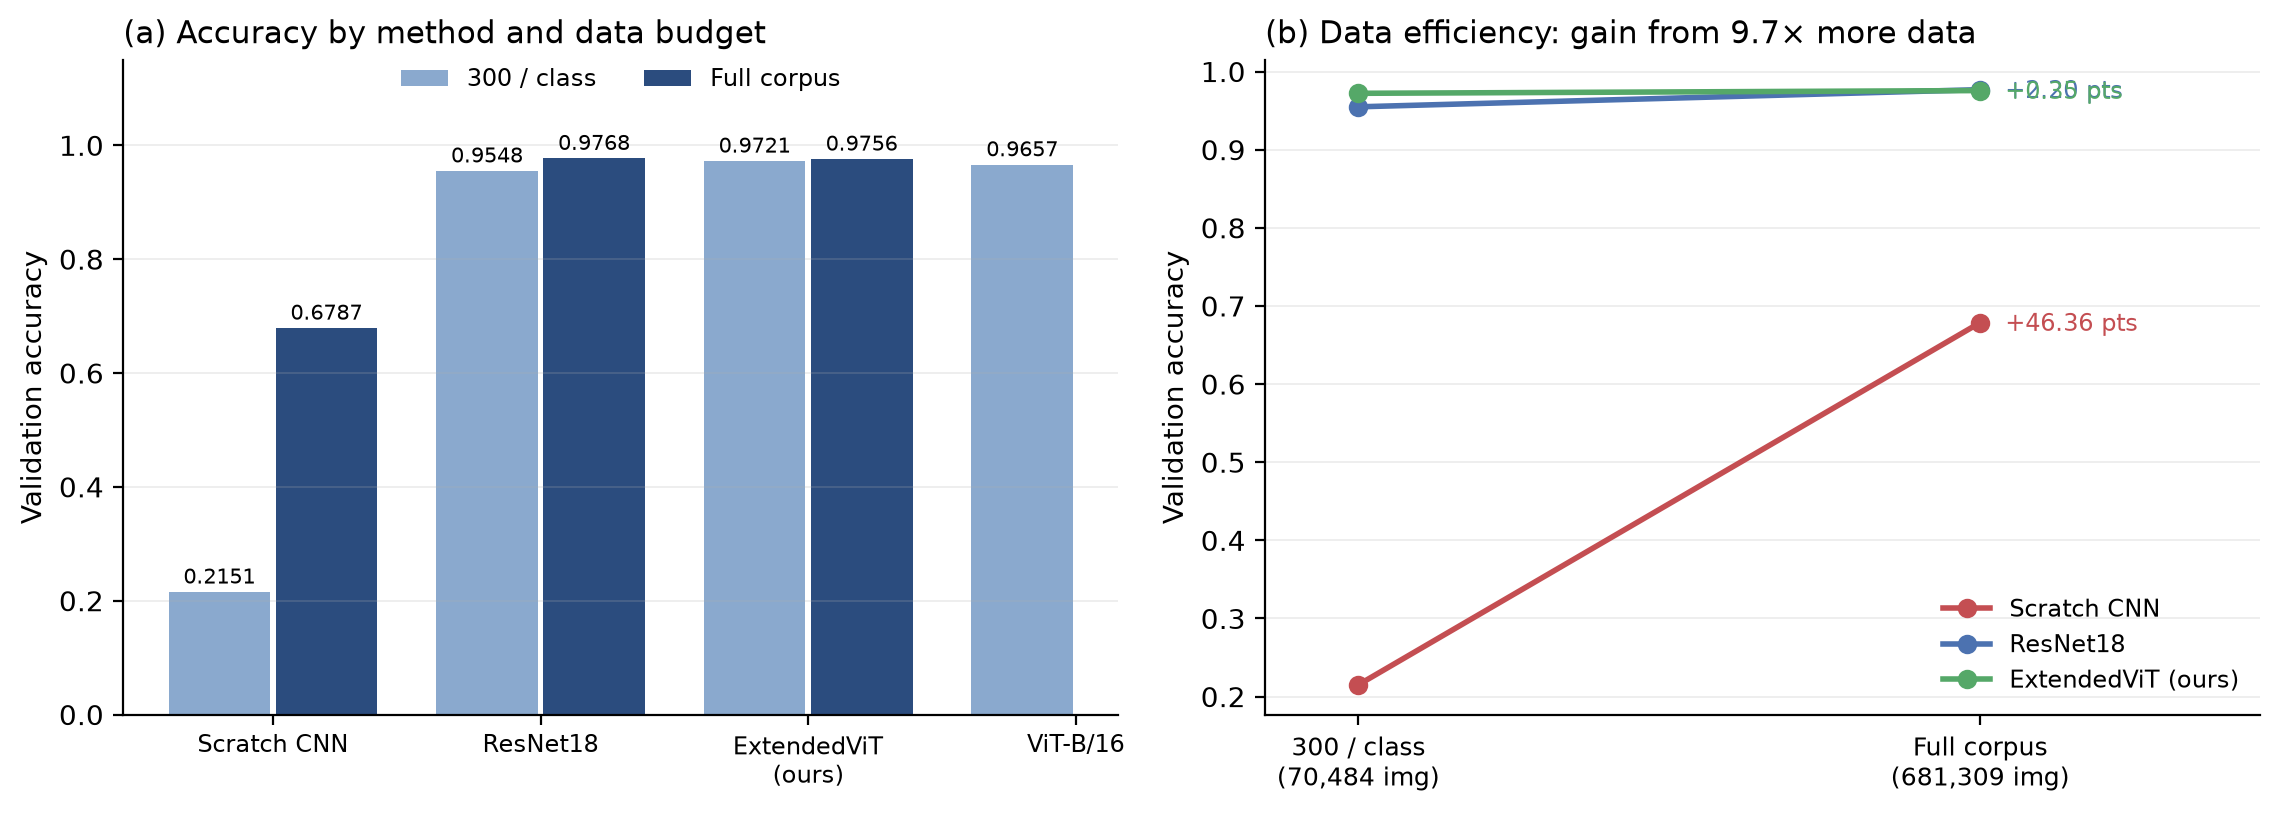

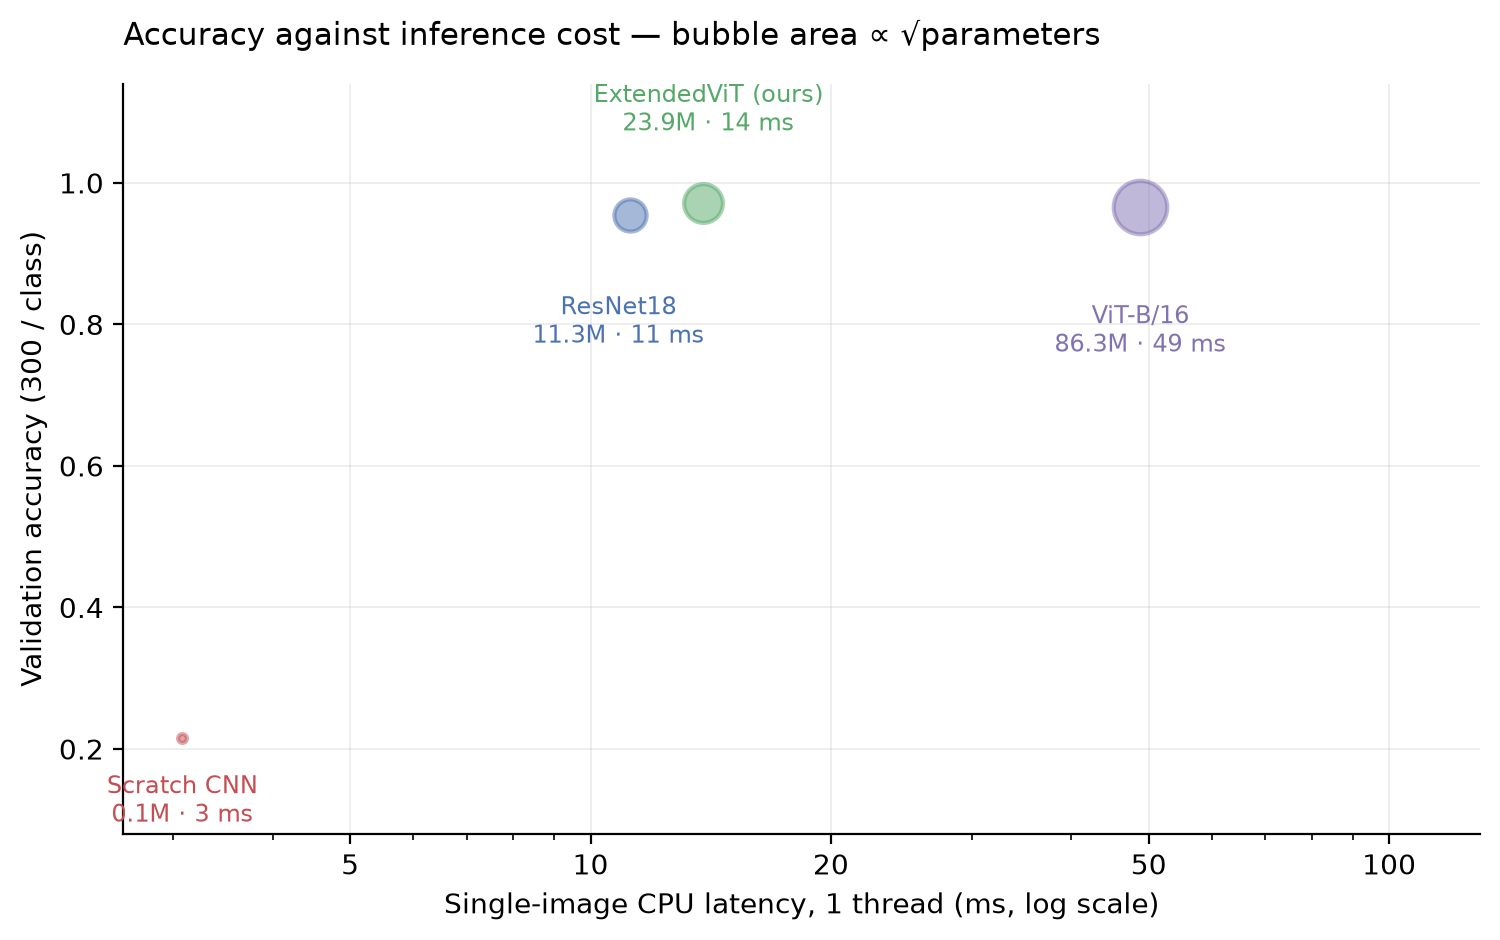

In [6]:
from IPython.display import Image, display
for f in ('fig6_training_curves', 'fig7_results', 'fig9_efficiency'):
    display(Image(f'../paper/{f}.png'))

## Confusion matrices

['../paper/confusion_full_cnn.png', '../paper/confusion_full_extended_vit.png', '../paper/confusion_full_resnet18.png', '../paper/confusion_lpc300_cnn.png', '../paper/confusion_lpc300_extended_vit.png', '../paper/confusion_lpc300_resnet18.png', '../paper/confusion_lpc300_vit.png']


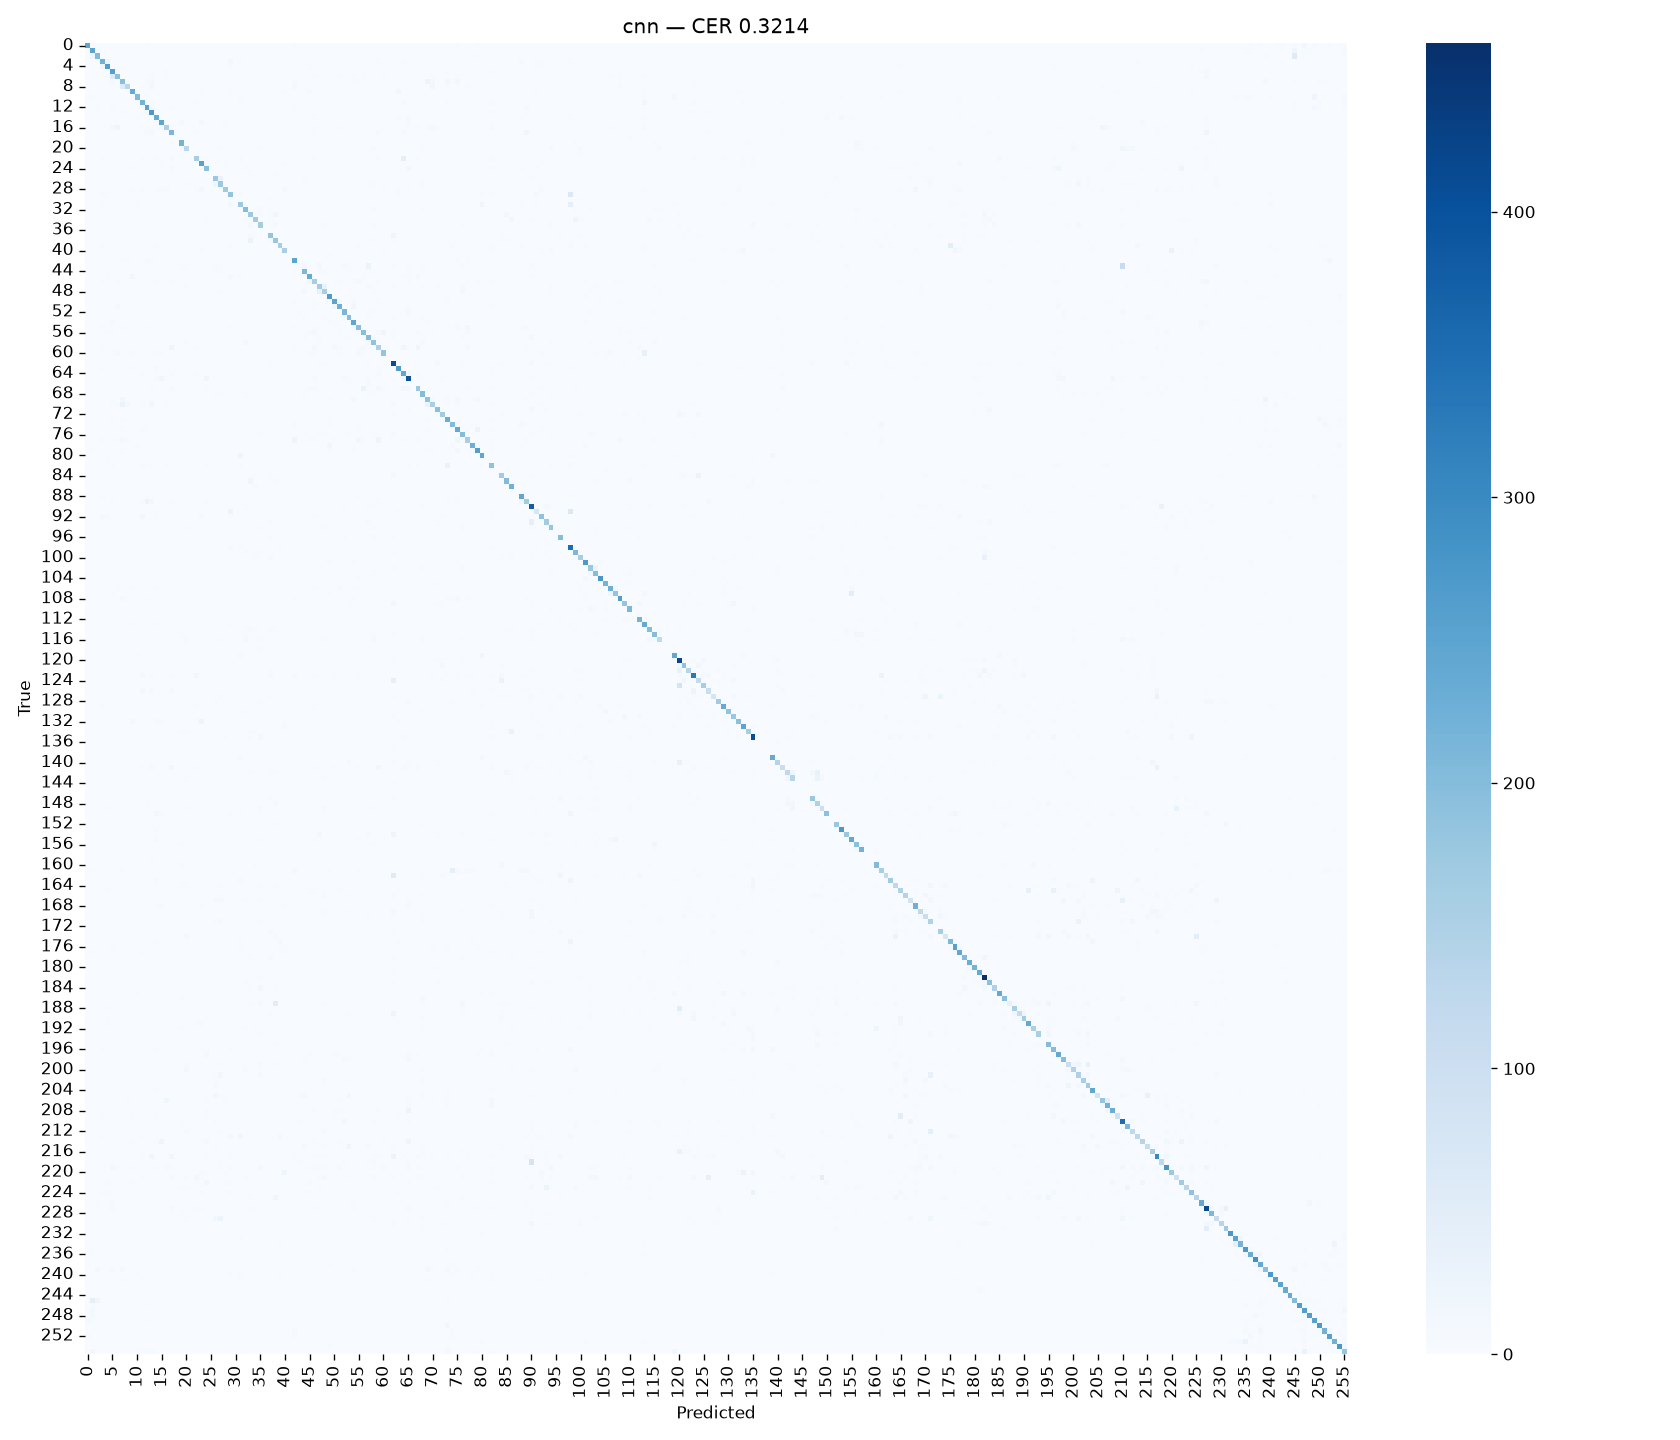

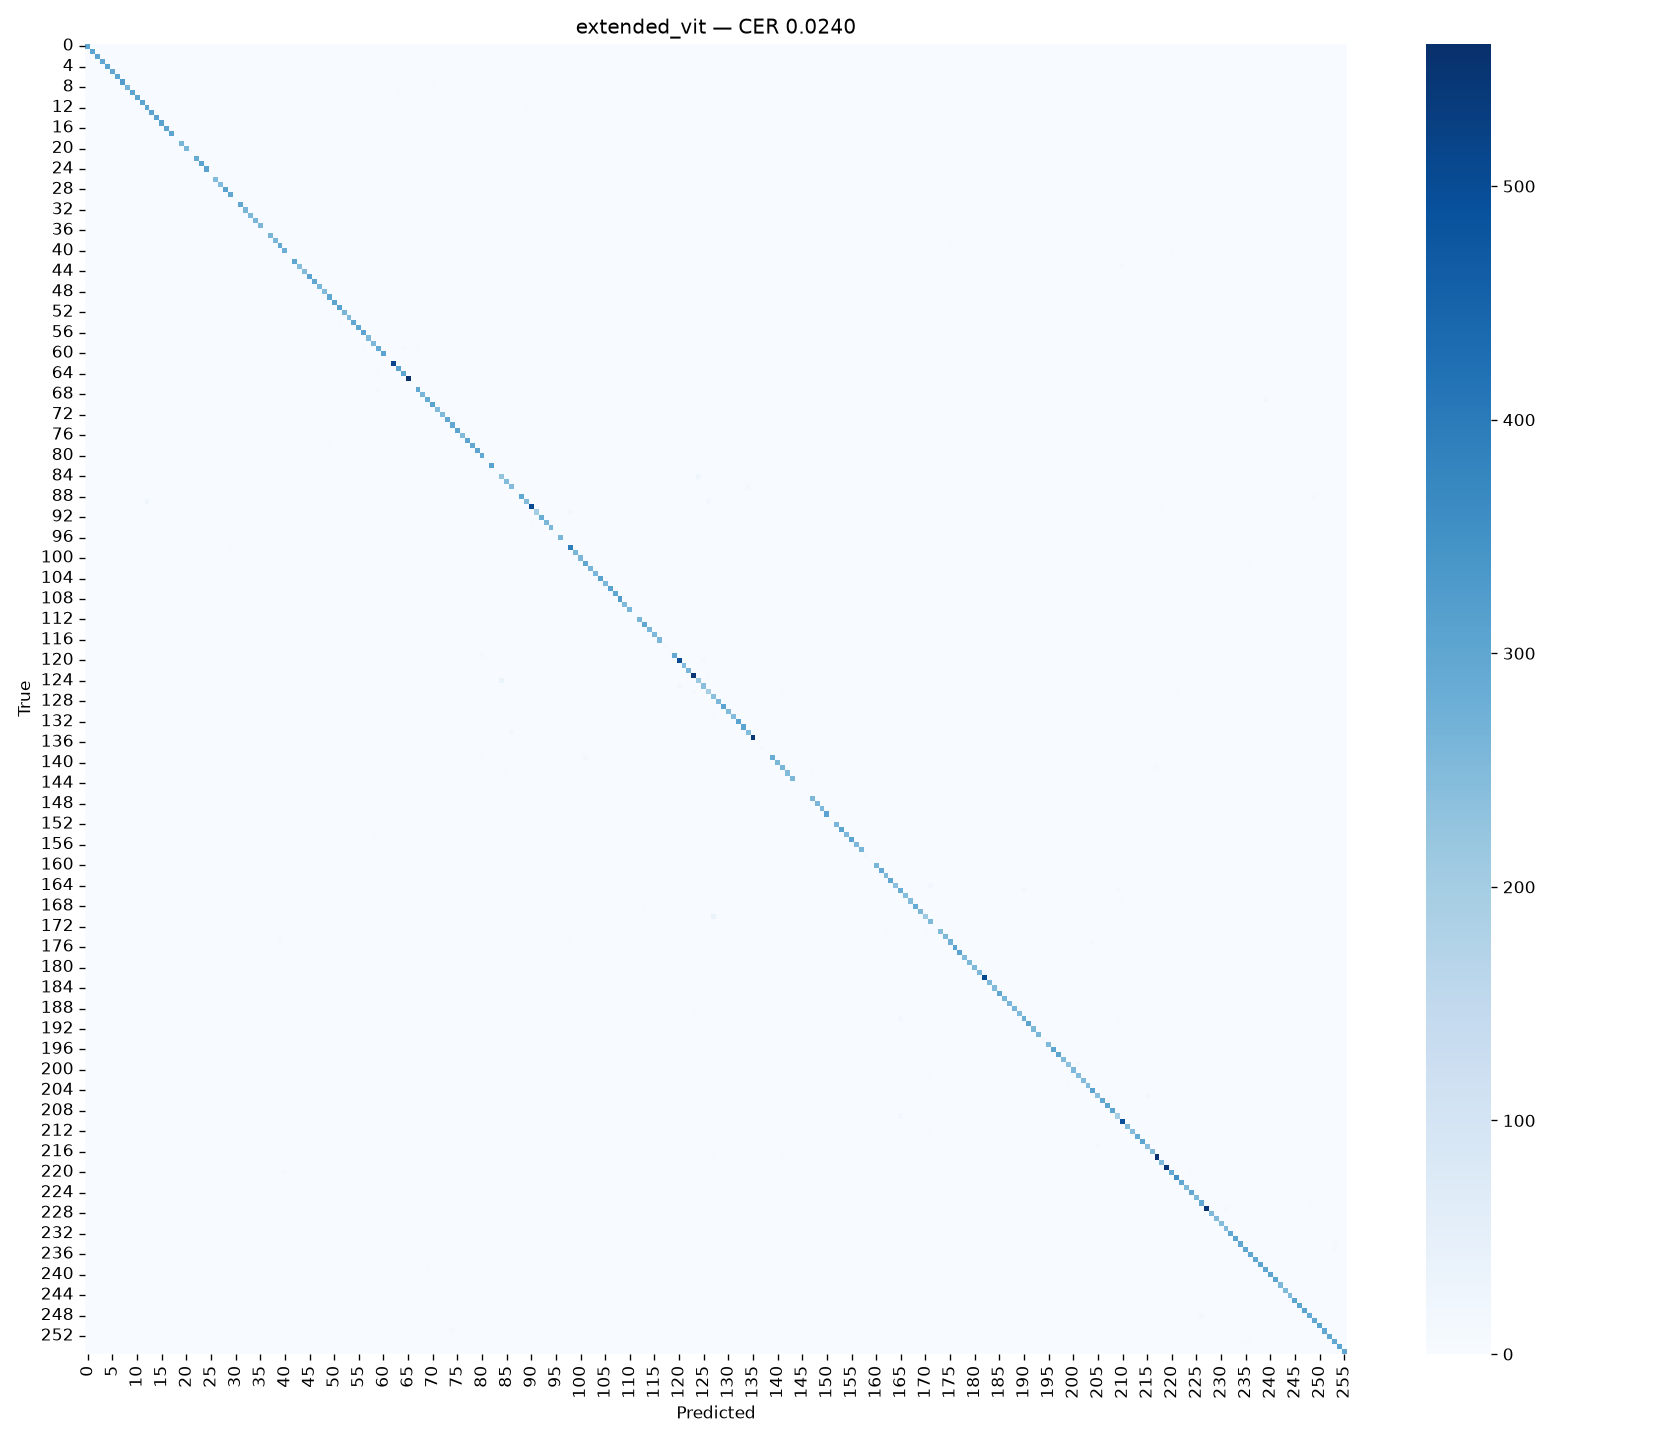

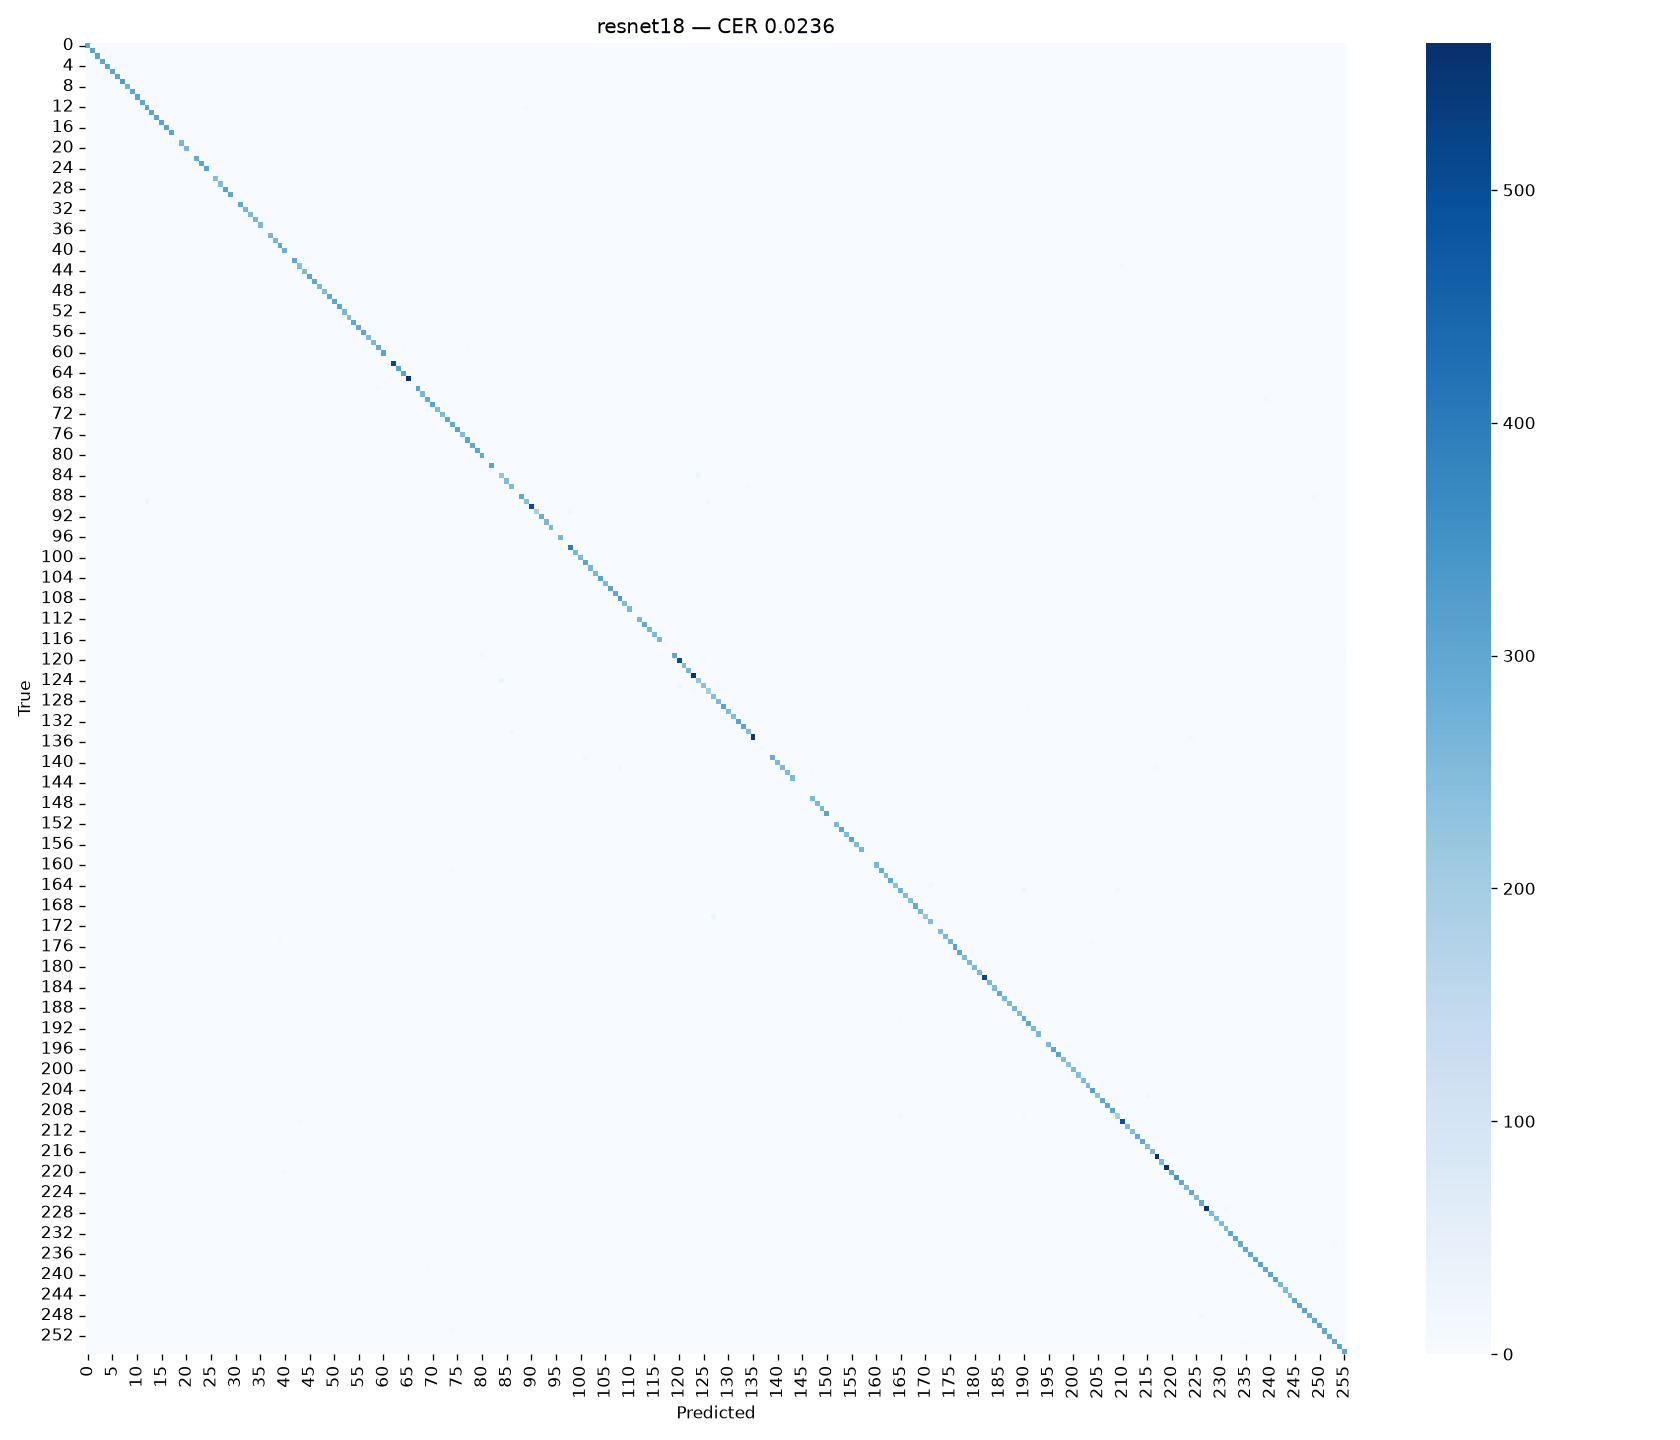

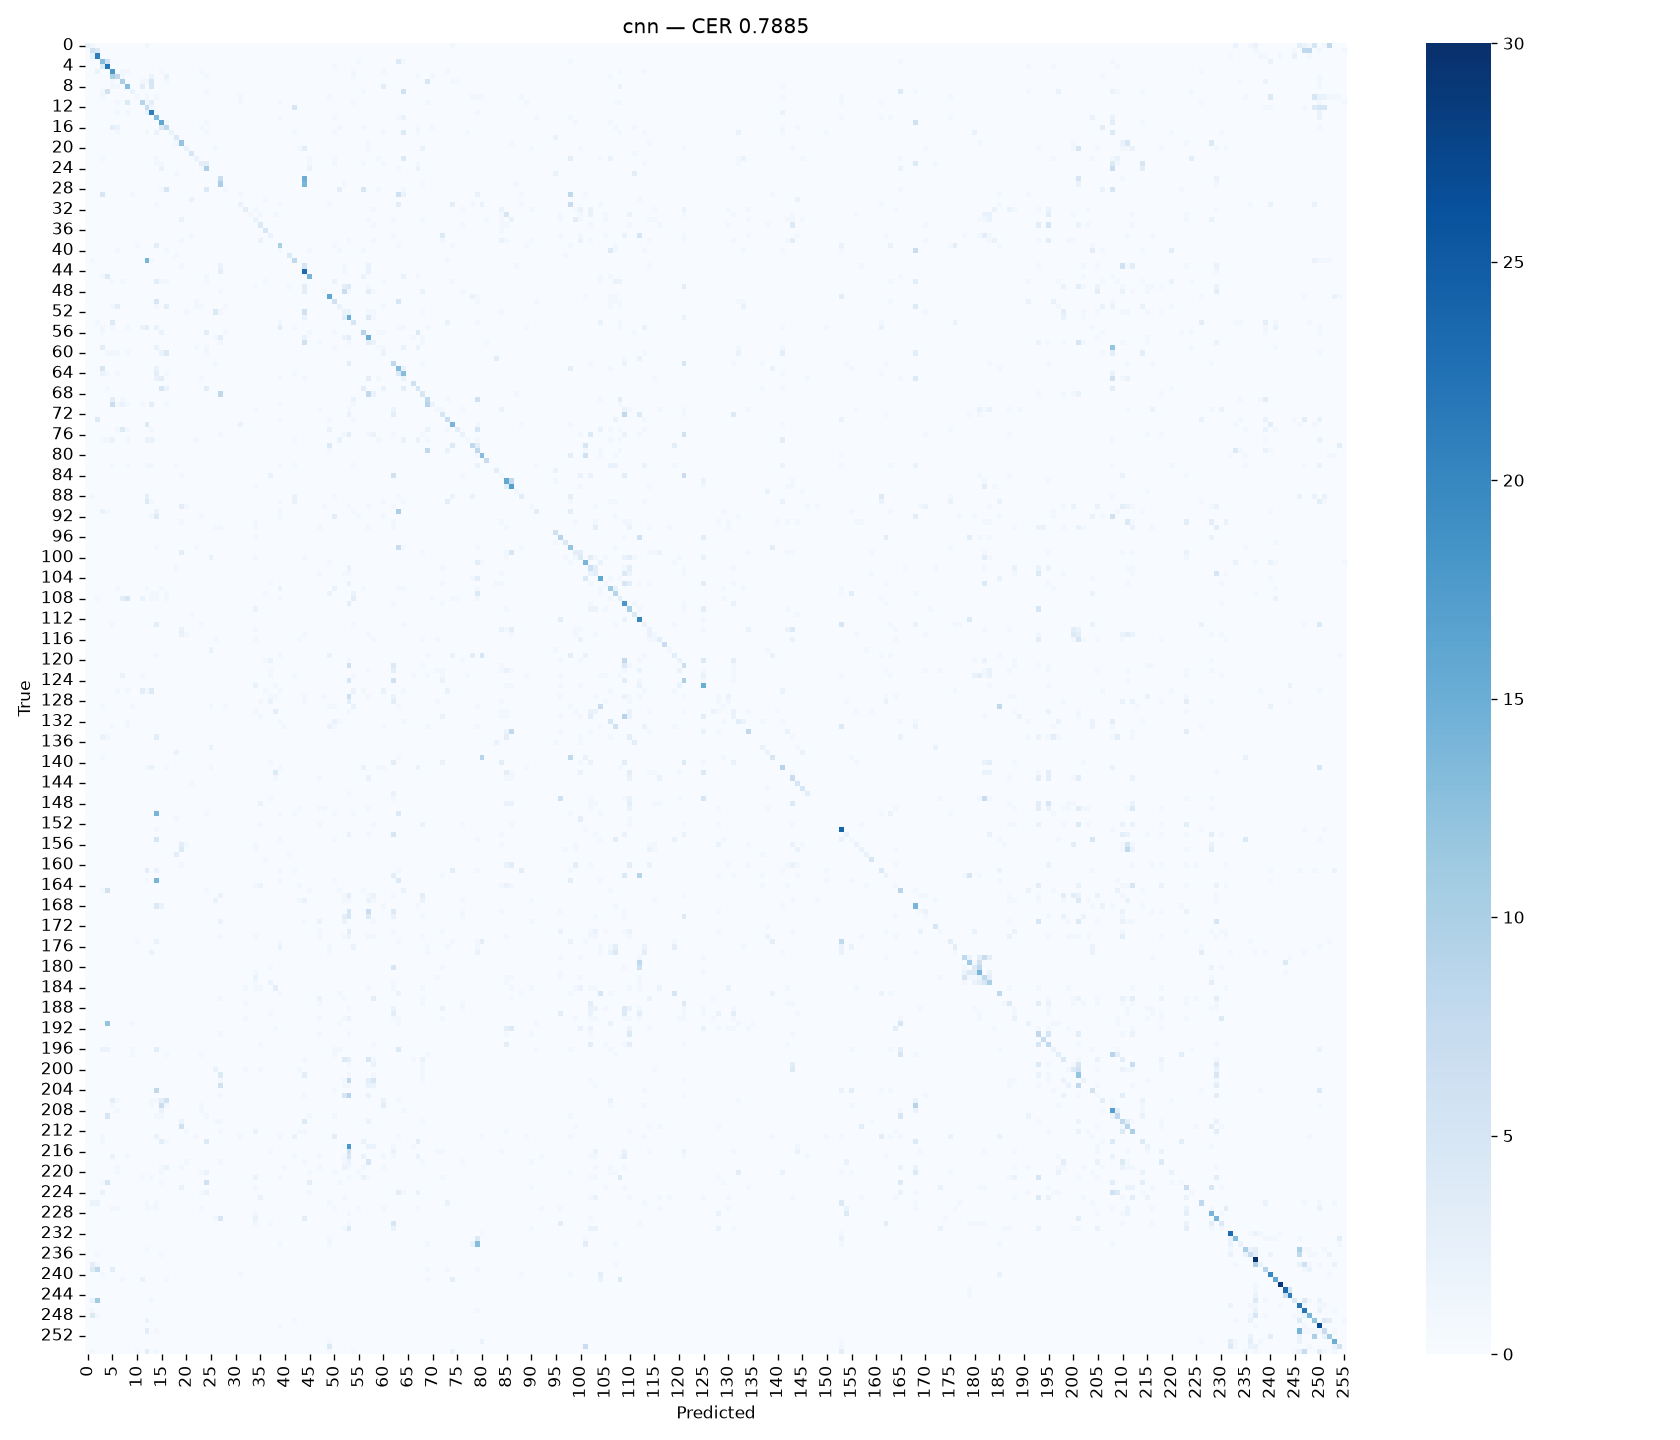

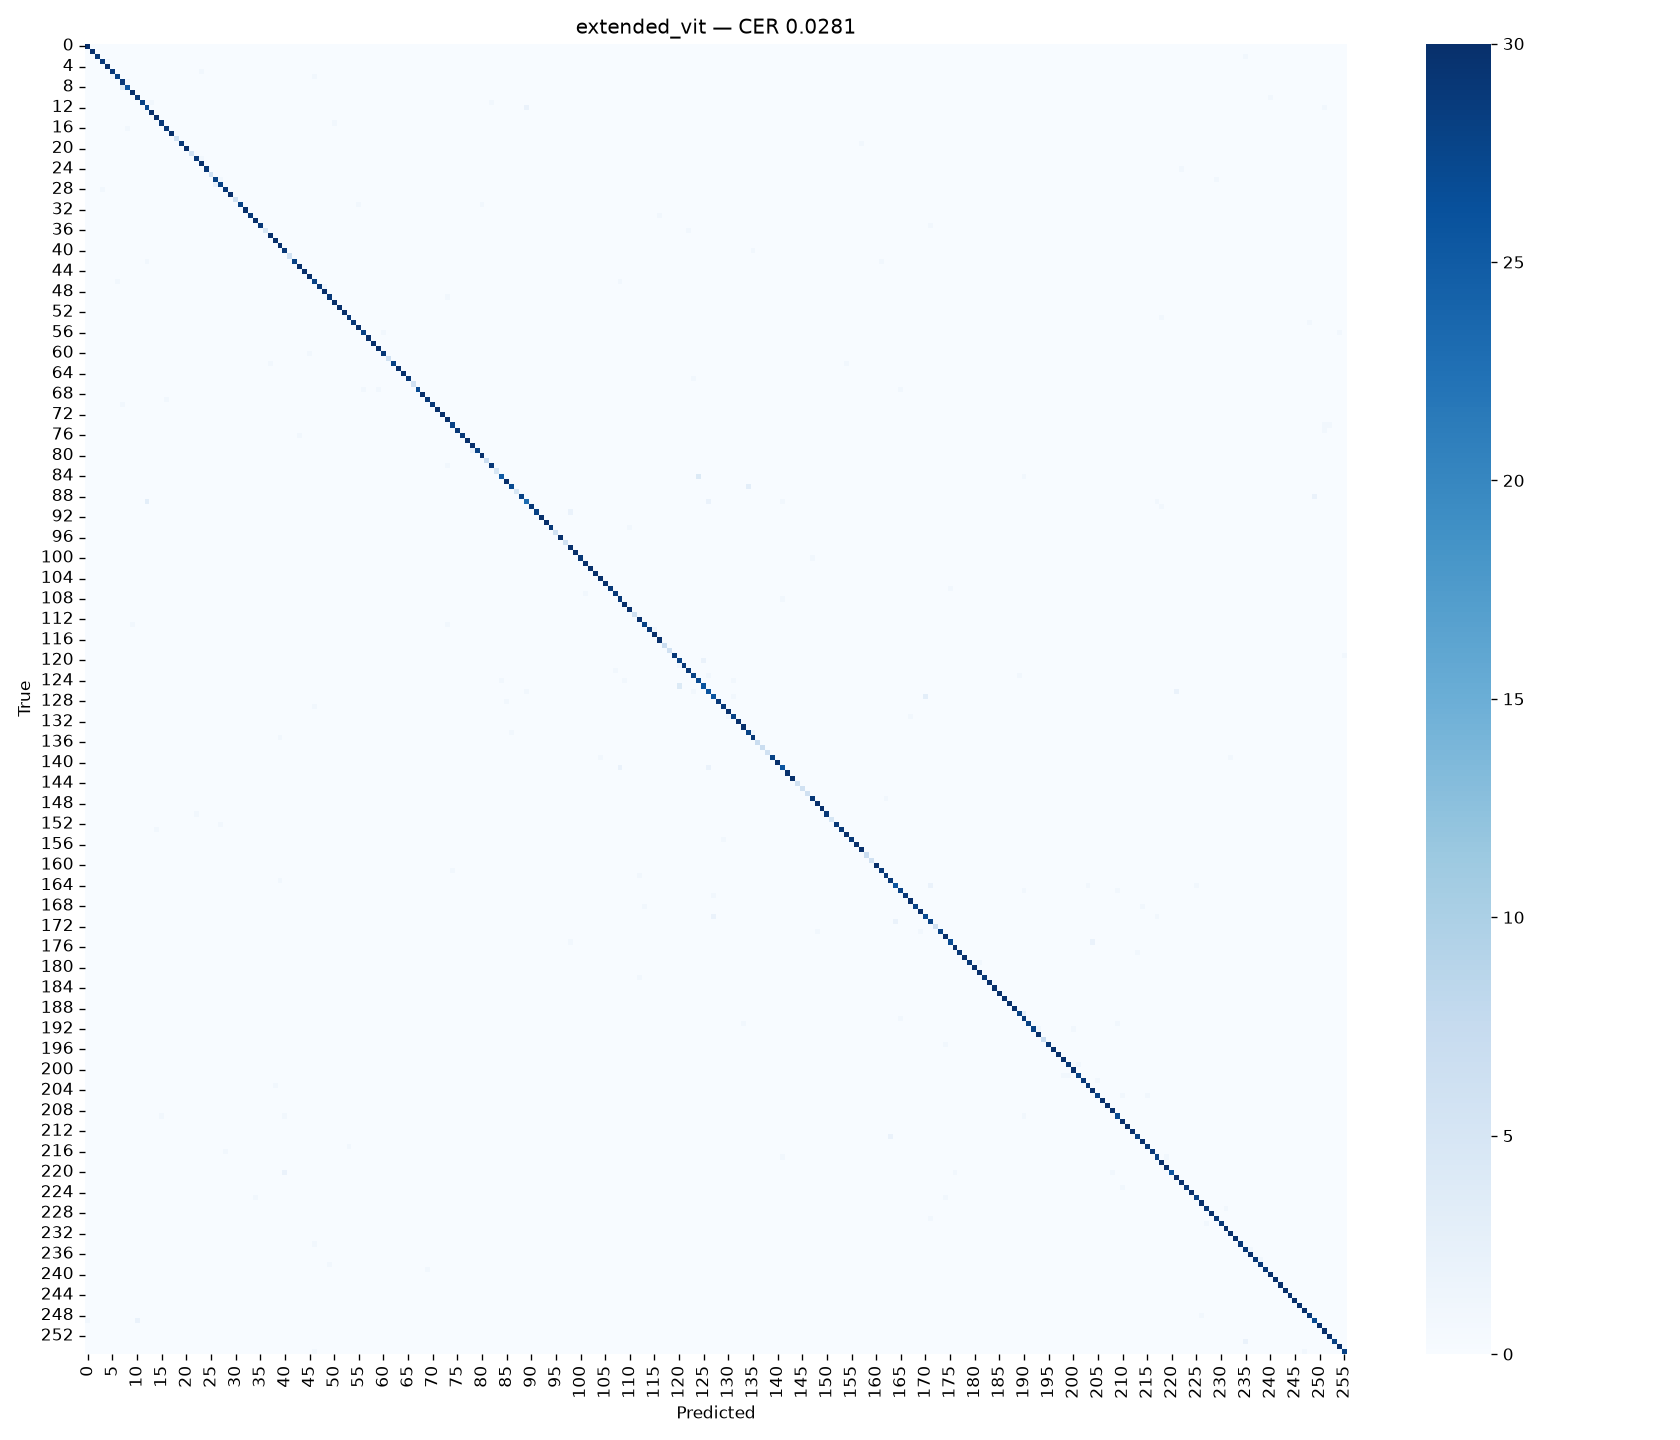

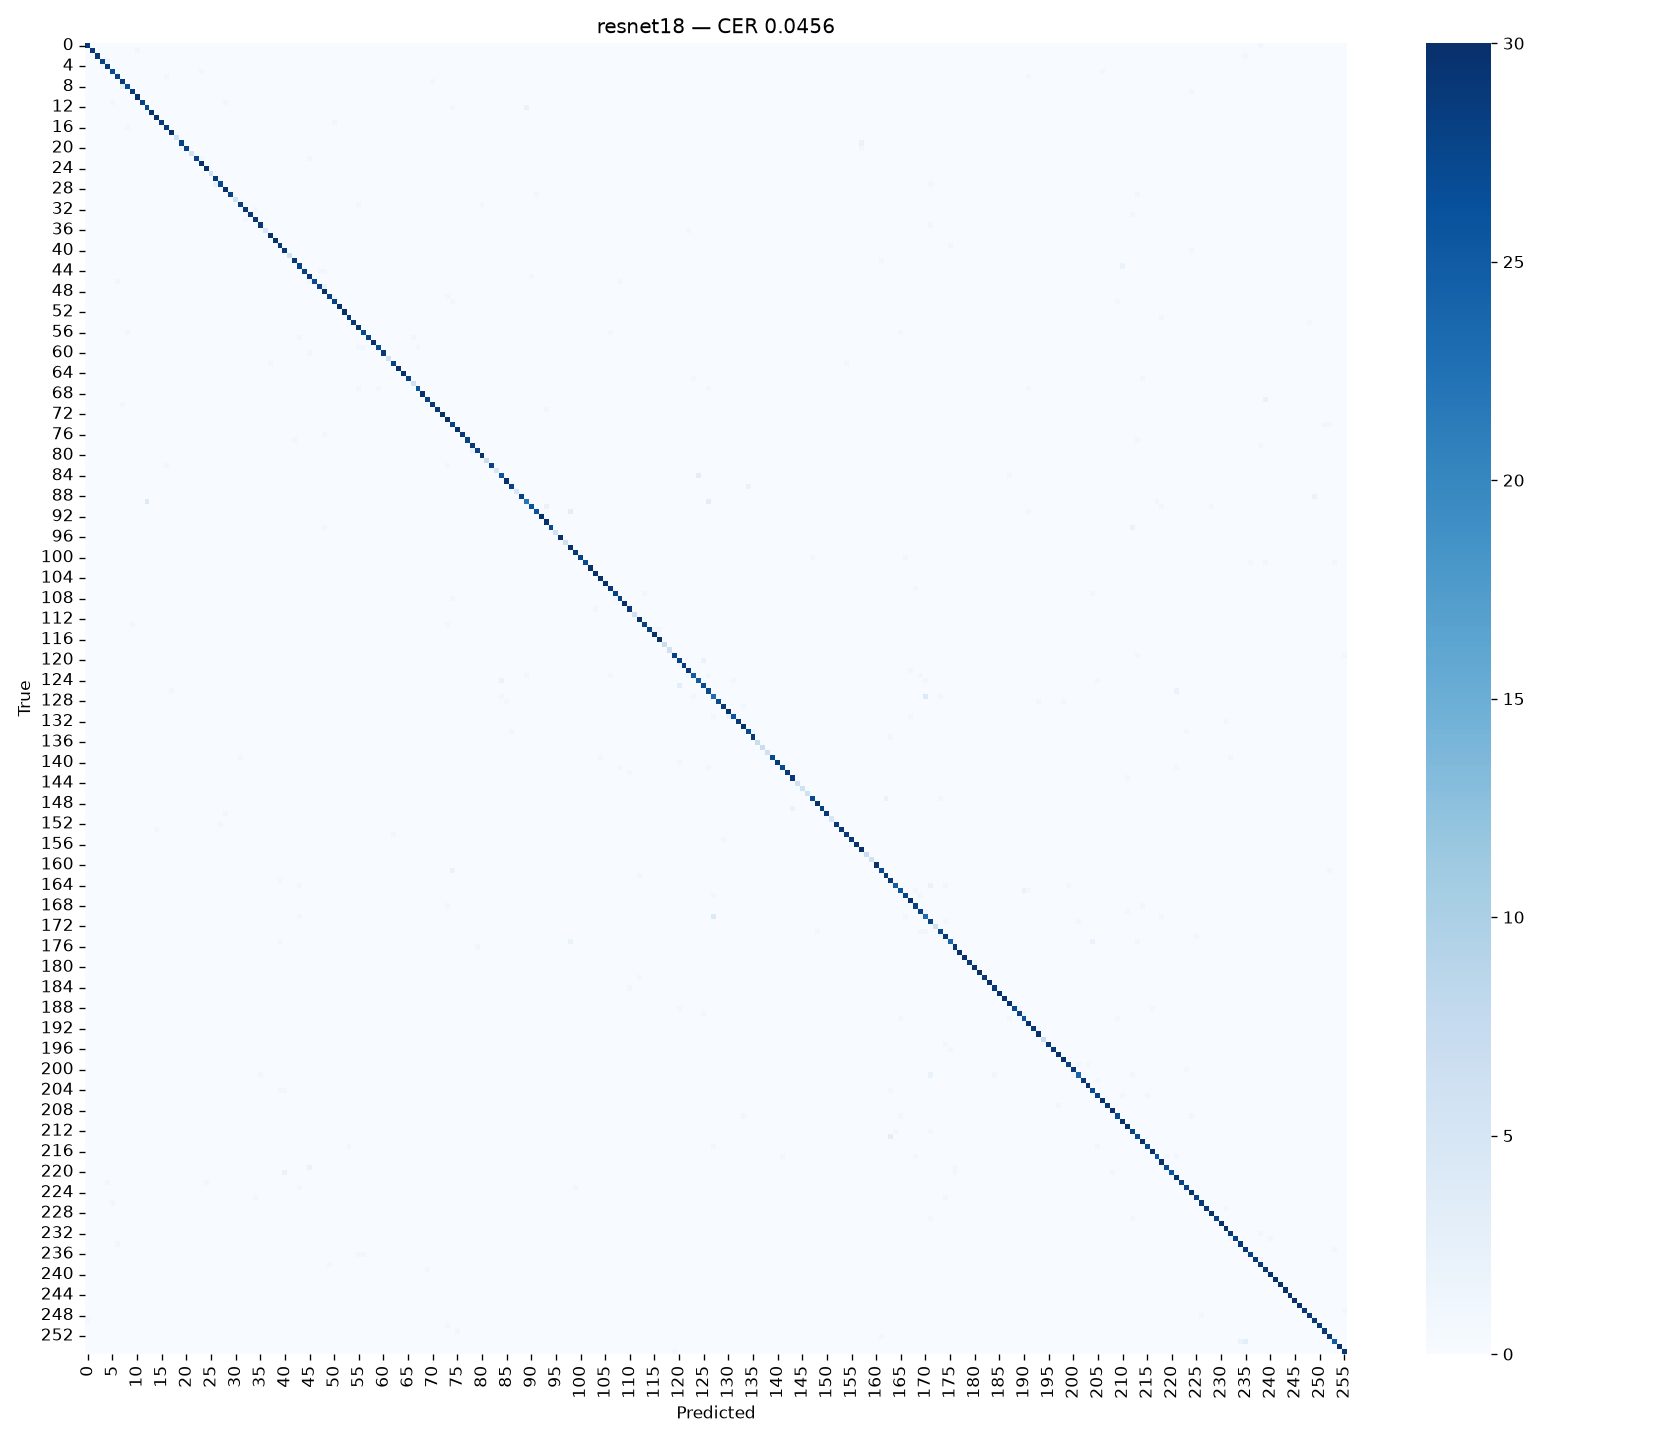

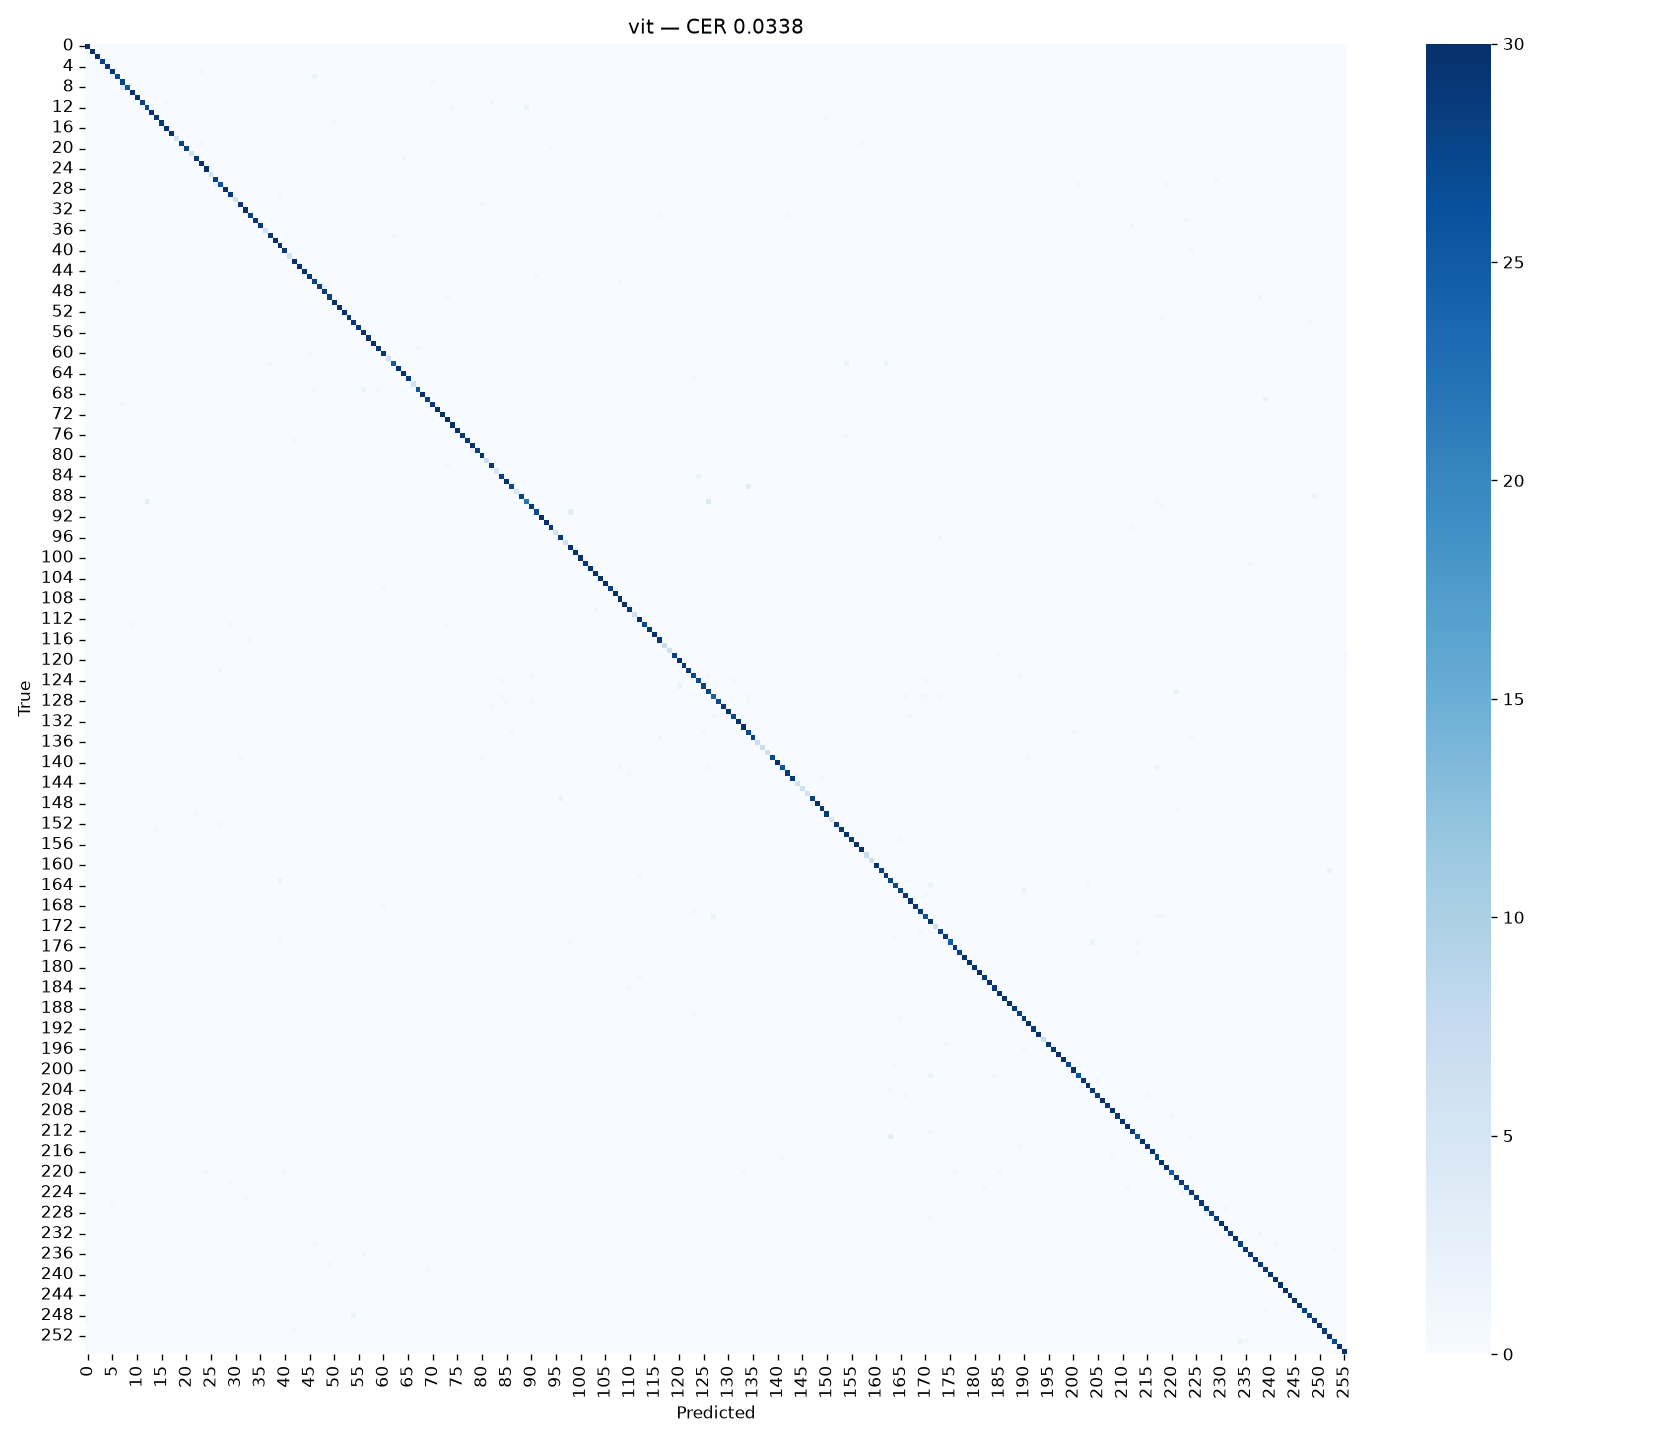

In [7]:
from IPython.display import Image, display
import glob
found = sorted(glob.glob('../paper/confusion_*.png'))
print(found if found else '(produced by evaluate.py --confusion)')
for f in found:
    display(Image(f))